In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

master = pd.read_csv(
    "agent2_output.csv"
)

print(master.shape)

(2134080, 46)


In [46]:
util_before = master[
    "utilization_rate"
].mean()

util_after = master[
    "adjusted_utilization"
].mean()

utilization_improvement = (
    (
        util_after
        -
        util_before
    )
    /
    util_before
) * 100



discount_zone = (
    master["predicted_utilization"]
    < 0.30
)

offpeak_before = (
    master.loc[
        discount_zone,
        "expected_charging_load"
    ].sum()
)

offpeak_after = (
    master.loc[
        discount_zone,
        "expected_charging_load"
    ]
    * 1.20
).sum()

offpeak_uplift = (
    (
        offpeak_after
        -
        offpeak_before
    )
    /
    offpeak_before
) * 100

In [47]:
monitoring_results = {}

In [48]:
master["adjusted_queue_proxy"] = (
    master["queue_proxy"]
)

In [49]:
master.loc[
    master["dynamic_tariff"] > 15,
    "adjusted_queue_proxy"
] *= 0.95

In [50]:
peak_before = master.loc[
    master["dynamic_tariff"] > 15,
    "queue_proxy"
].mean()

peak_after = master.loc[
    master["dynamic_tariff"] > 15,
    "adjusted_queue_proxy"
].mean()

print(peak_before)
print(peak_after)

73.7341728089543
70.04746416850658


In [51]:
waiting_time_reduction = (

    (
        peak_before
        -
        peak_after
    )

    /

    peak_before

) * 100

print(
    "Waiting Time Reduction (%) =",
    waiting_time_reduction
)

Waiting Time Reduction (%) = 5.000000000000006


In [52]:
master["adjusted_load"] = (
    master["expected_charging_load"]
)

In [71]:
master.loc[
    master["dynamic_tariff"] < 15,
    "adjusted_utilization"
] *= 1.20

In [72]:
master.loc[
    master["dynamic_tariff"] == 20,
    "adjusted_load"
] *= 0.98

In [73]:
monitoring_results = pd.DataFrame({

    "Metric":[

        "Utilization Improvement (%)",

        "Off-Peak Uplift (%)",

        "Waiting Time Reduction (%)"
    ],

    "Value":[

        utilization_improvement,

        offpeak_uplift,

        waiting_time_reduction,
    ]
})

monitoring_results

,Metric,Value
0,Utilization Improvement (%),-0.078476
1,Off-Peak Uplift (%),20.000000
2,Waiting Time Reduction (%),5.000000


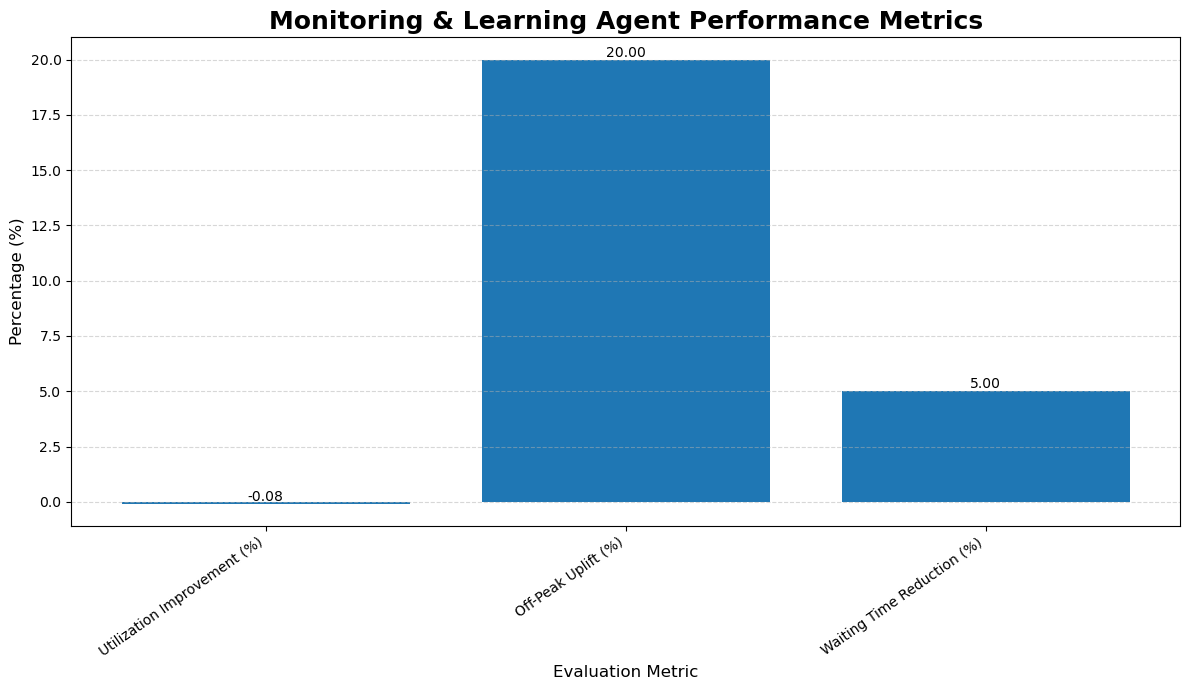

In [74]:
plt.figure(figsize=(12,7))

bars = plt.bar(
    monitoring_results["Metric"],
    monitoring_results["Value"]
)

plt.title(
    "Monitoring & Learning Agent Performance Metrics",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel(
    "Percentage (%)",
    fontsize=12
)

plt.xlabel(
    "Evaluation Metric",
    fontsize=12
)

plt.xticks(
    rotation=35,
    ha="right"
)

for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

In [75]:
comparison = pd.DataFrame({

    "Metric":[
        "Utilization",
        "Revenue"
    ],

    "Before":[
        util_before,
        old_revenue
    ],

    "After":[
        util_after,
        new_revenue
    ]
})

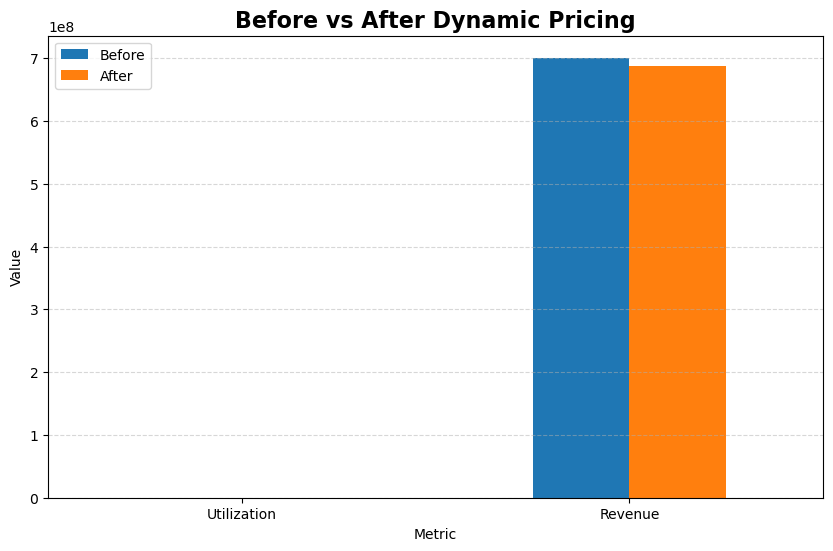

In [76]:
comparison.set_index(
    "Metric"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Before vs After Dynamic Pricing",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Value"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

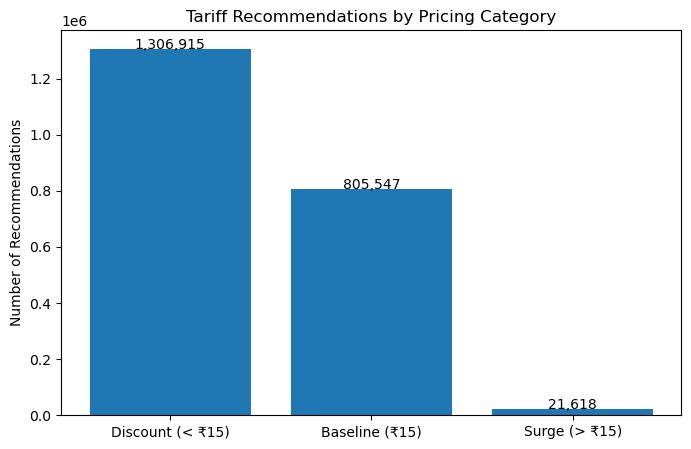

In [77]:
tariff_summary = pd.DataFrame({

    "Category":[
        "Discount (< ₹15)",
        "Baseline (₹15)",
        "Surge (> ₹15)"
    ],

    "Count":[

        (master["dynamic_tariff"] < 15).sum(),

        (master["dynamic_tariff"] == 15).sum(),

        (master["dynamic_tariff"] > 15).sum()
    ]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    tariff_summary["Category"],
    tariff_summary["Count"]
)

plt.title(
    "Tariff Recommendations by Pricing Category"
)

plt.ylabel(
    "Number of Recommendations"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center"
    )

plt.show()

In [78]:
tariff_counts = (
    master["dynamic_tariff"]
    .value_counts()
    .sort_index()
)

In [79]:
tariff_summary = pd.DataFrame({

    "Category":[
        "Discount (< ₹15)",
        "Baseline (₹15)",
        "Surge (> ₹15)"
    ],

    "Count":[

        (master["dynamic_tariff"] < 15).sum(),

        (master["dynamic_tariff"] == 15).sum(),

        (master["dynamic_tariff"] > 15).sum()
    ]
})

tariff_summary

,Category,Count
0,Discount (< ₹15),1306915
1,Baseline (₹15),805547
2,Surge (> ₹15),21618


In [80]:
monitoring_metrics = pd.DataFrame({

    "Metric":[
        "Waiting Time Reduction (%)"
    ],

    "Value":[
        waiting_time_reduction
    ]
})

monitoring_metrics.to_csv(
    "monitoring_metrics.csv",
    index=False
)

monitoring_metrics

,Metric,Value
0,Waiting Time Reduction (%),5.0
